# Medical Insurance Cost Prediction Using Linear Regression



### Objectives
- Understand regression problems
- Perform Exploratory Data Analysis (EDA)
- Preprocess data
- Train Linear Regression model
- Evaluate model performance
- Interpret results

### Dataset
Medical Cost Personal Dataset from Kaggle



### Step 1 — Import Libraries


In [1]:

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import warnings
warnings.filterwarnings('ignore')

###  Step 2 — Load Dataset

In [2]:
df = pd.read_csv('insurance.csv')
df.head()

,age,sex,bmi,children,smoker,region,charges
0,19,female,27.900,0,yes,southwest,16884.92400
1,18,male,33.770,1,no,southeast,1725.55230
2,28,male,33.000,3,no,southeast,4449.46200
3,33,male,22.705,0,no,northwest,21984.47061
4,32,male,28.880,0,no,northwest,3866.85520


In [3]:
df.tail()

,age,sex,bmi,children,smoker,region,charges
1333,50,male,30.97,3,no,northwest,10600.5483
1334,18,female,31.92,0,no,northeast,2205.9808
1335,18,female,36.85,0,no,southeast,1629.8335
1336,21,female,25.80,0,no,southwest,2007.9450
1337,61,female,29.07,0,yes,northwest,29141.3603



### Step 3 — Understand the Dataset


In [4]:
df.shape
#total rows and cols

(1338, 7)

In [5]:
df.info()
#datatype info

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1338 entries, 0 to 1337
Data columns (total 7 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1338 non-null   int64  
 1   sex       1338 non-null   object 
 2   bmi       1338 non-null   float64
 3   children  1338 non-null   int64  
 4   smoker    1338 non-null   object 
 5   region    1338 non-null   object 
 6   charges   1338 non-null   float64
dtypes: float64(2), int64(2), object(3)
memory usage: 73.3+ KB


In [6]:
df.describe()
#stati info

,age,bmi,children,charges
count,1338.000000,1338.000000,1338.000000,1338.000000
mean,39.207025,30.663397,1.094918,13270.422265
std,14.049960,6.098187,1.205493,12110.011237
min,18.000000,15.960000,0.000000,1121.873900
25%,27.000000,26.296250,0.000000,4740.287150
50%,39.000000,30.400000,1.000000,9382.033000
75%,51.000000,34.693750,2.000000,16639.912515
max,64.000000,53.130000,5.000000,63770.428010


In [7]:
df.isnull().sum()
#check any missing

age         0
sex         0
bmi         0
children    0
smoker      0
region      0
charges     0
dtype: int64

In [8]:
df.duplicated().sum()
#check for duplicates

np.int64(1)

In [9]:
df = df.drop_duplicates()

In [10]:
df.duplicated().sum()
#check if duplicate dropped

np.int64(0)

In [11]:
df.shape

(1337, 7)

In [12]:
df.columns
#cols after removing dup row

Index(['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges'], dtype='object')

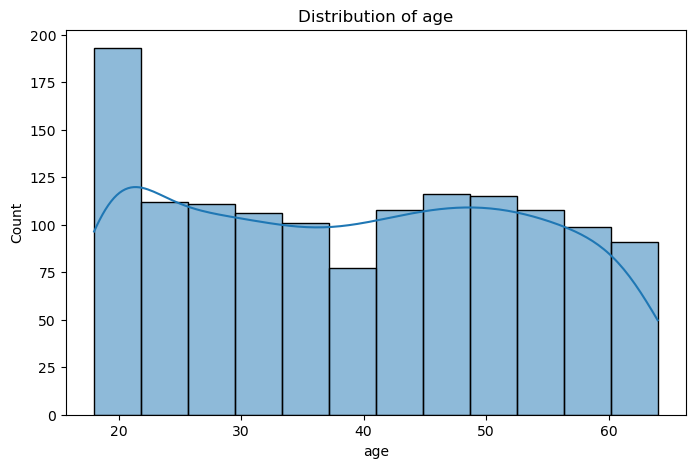

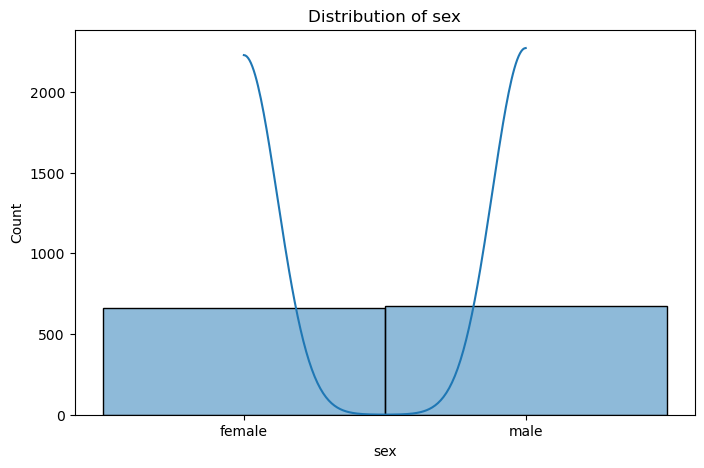

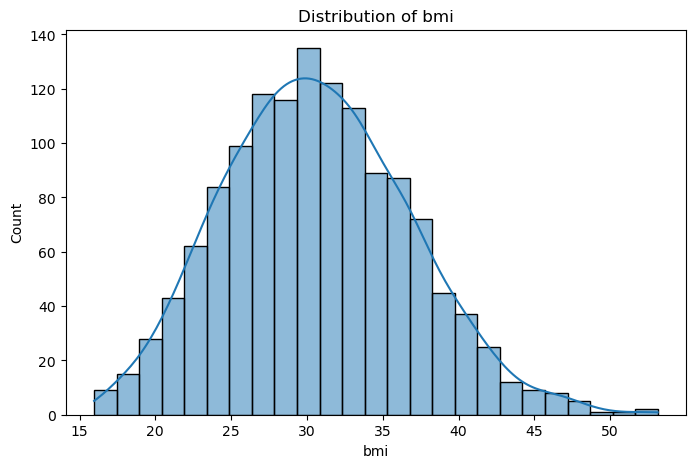

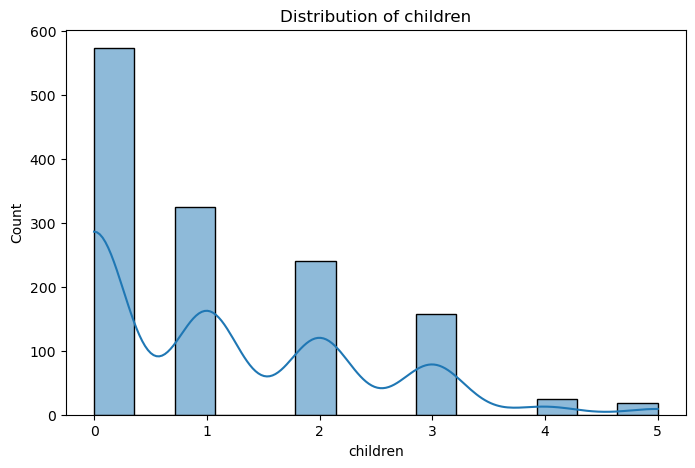

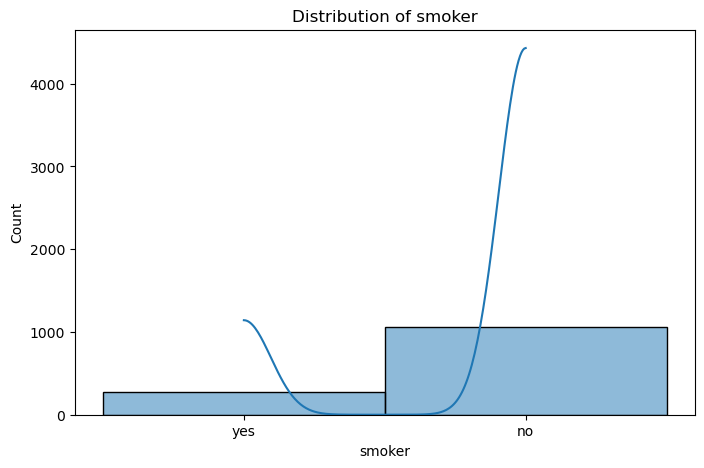

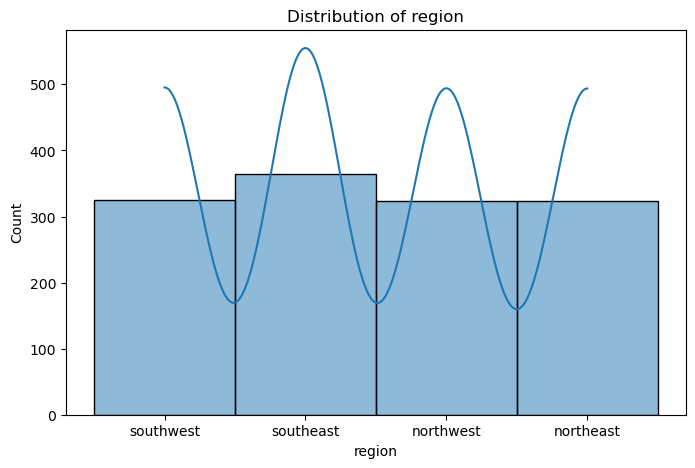

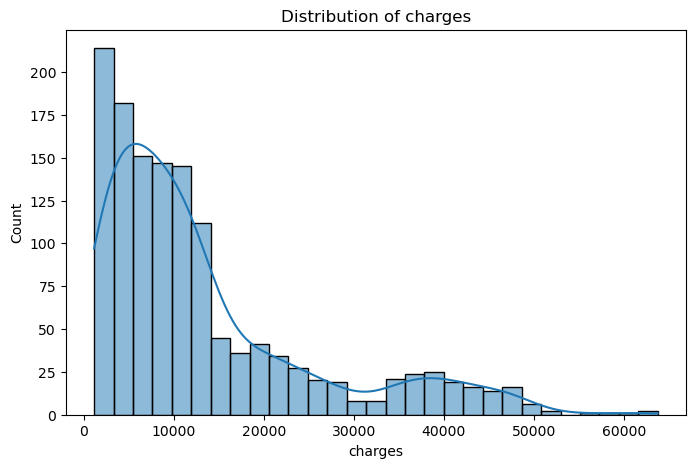

In [13]:
cols=['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

for col in cols:
    plt.figure(figsize=(8,5))
    sns.histplot(df[col], kde=True)
    plt.title(f'Distribution of {col}')
    plt.show()
#plot histogram on all the independent variables with loop

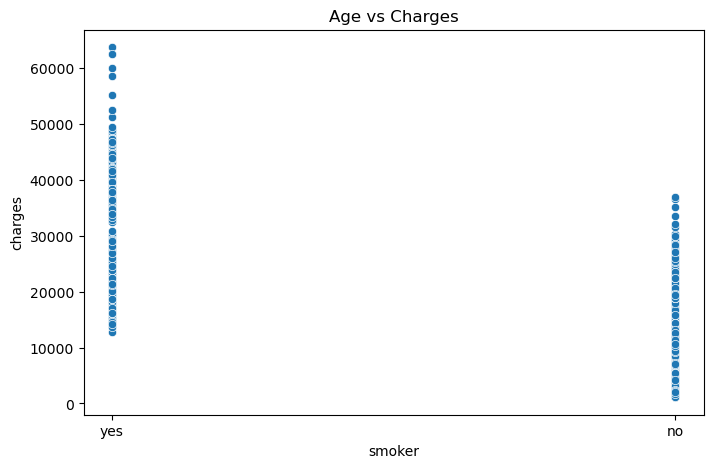

In [14]:
plt.figure(figsize=(8,5))
sns.scatterplot(x='smoker', y='charges', data=df)
plt.title('Age vs Charges')
plt.show()
# smoking vs charges

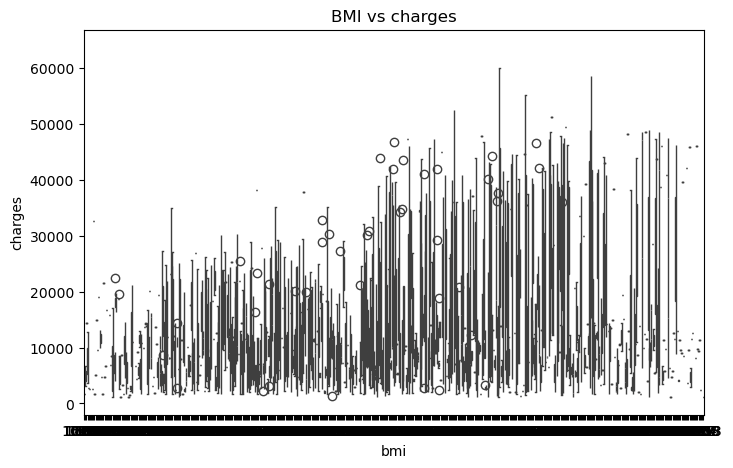

In [15]:
plt.figure(figsize=(8,5))
sns.boxplot(x='bmi', y='charges', data=df)
plt.title('BMI vs charges')
plt.show()
# BMI vs Charges

### Step 5 — Data Preprocessing

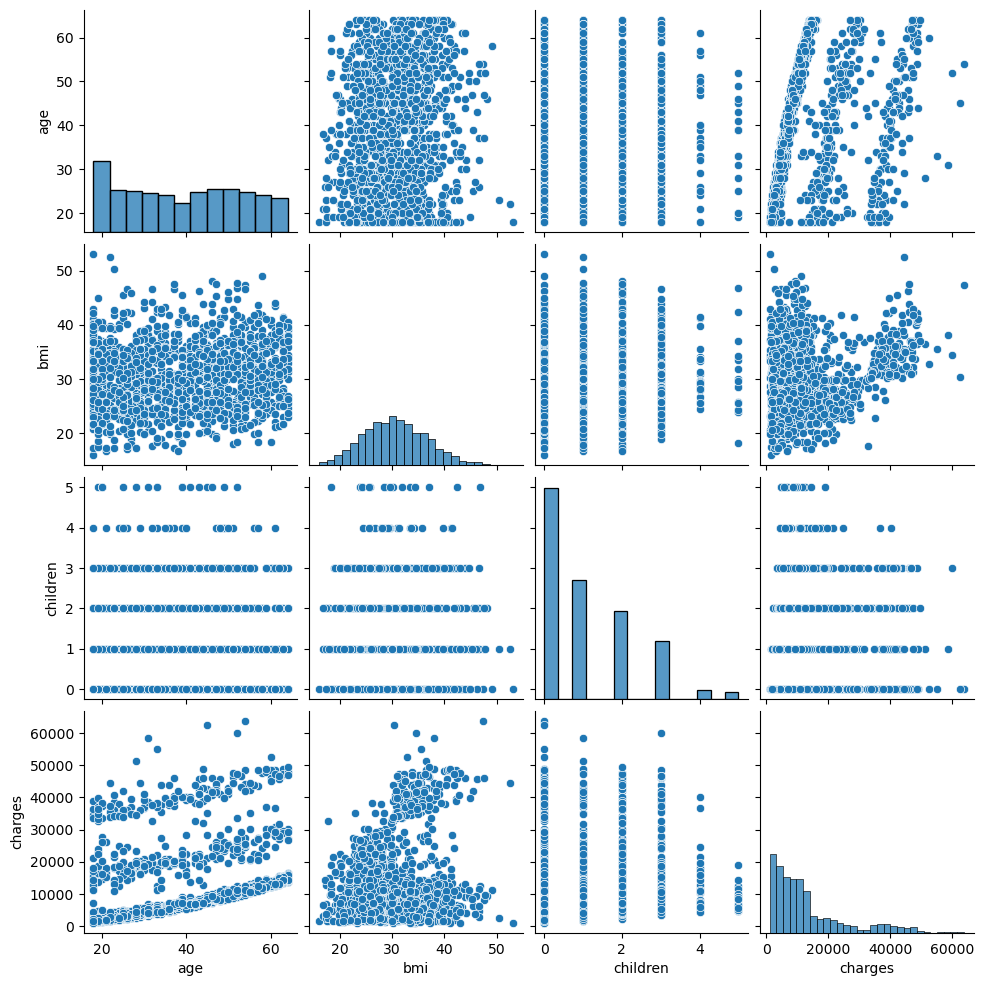

In [16]:
sns.pairplot(df)
plt.show()
# pairplot

In [17]:
print(df['sex'].value_counts())
print(df['smoker'].value_counts())
print(df['region'].value_counts())
#checking count of string values in dataset

sex
male      675
female    662
Name: count, dtype: int64
smoker
no     1063
yes     274
Name: count, dtype: int64
region
southeast    364
southwest    325
northwest    324
northeast    324
Name: count, dtype: int64


In [18]:
df[['sex','smoker','region']].head()
#display 5 values of the string data in set

,sex,smoker,region
0,female,yes,southwest
1,male,no,southeast
2,male,no,southeast
3,male,no,northwest
4,male,no,northwest


In [19]:
le = LabelEncoder()

df['sex'] = le.fit_transform(df['sex'])
df['smoker'] = le.fit_transform(df['smoker'])
df['region'] = le.fit_transform(df['region'])

df.head()
# changing string to int values

,age,sex,bmi,children,smoker,region,charges
0,19,0,27.900,0,1,3,16884.92400
1,18,1,33.770,1,0,2,1725.55230
2,28,1,33.000,3,0,2,4449.46200
3,33,1,22.705,0,0,1,21984.47061
4,32,1,28.880,0,0,1,3866.85520


In [20]:
print(df['sex'].value_counts())
print(df['smoker'].value_counts())
print(df['region'].value_counts())
#check if count matches

sex
1    675
0    662
Name: count, dtype: int64
smoker
0    1063
1     274
Name: count, dtype: int64
region
2    364
3    325
1    324
0    324
Name: count, dtype: int64


In [21]:
df.dtypes
#check if the strings changed

age           int64
sex           int64
bmi         float64
children      int64
smoker        int64
region        int64
charges     float64
dtype: object

### Step 6 — Correlation Heatmap

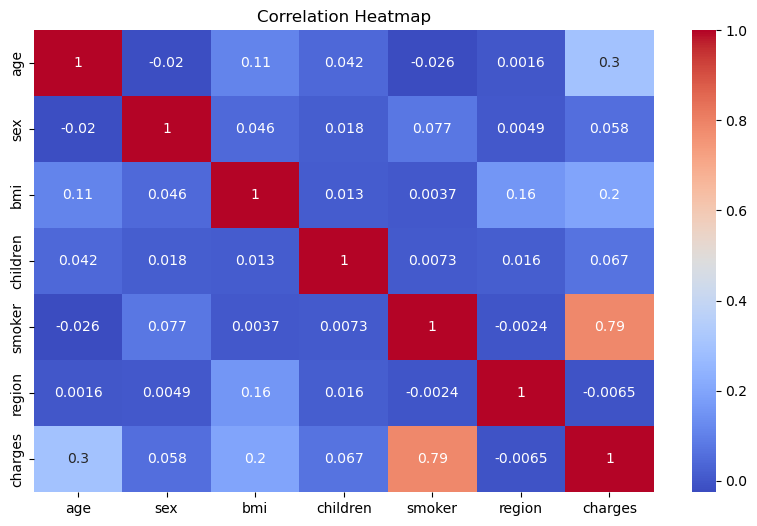

In [22]:

plt.figure(figsize=(10,6))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title('Correlation Heatmap')
plt.show()
#use heatmap to identify corelation faster

### Step 7 — Define Features and Target

In [23]:
X = df.drop('charges', axis=1)
y = df['charges']
#defining features and target

#### Step 8 — Split the Dataset

In [24]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training Data Shape:", X_train.shape)
print("Testing Data Shape:", X_test.shape)
#defining the train,test split

Training Data Shape: (1069, 6)
Testing Data Shape: (268, 6)


### Step 9 — Build Linear Regression Model

In [25]:
model = LinearRegression()
model.fit(X_train, y_train)
#build model

,fit_intercept,True
,copy_X,True
,tol,1e-06
,n_jobs,None
,positive,False


### Step 10 — Model Prediction

In [26]:
y_pred = model.predict(X_test)
y_pred[:5]
#calculate the ypred and display the  first 5 values

array([ 8080.45018585,  5592.87111988, 14378.29865472, 31731.81954139,
        9158.3569444 ])

### Step 11 — Model Coefficients

In [27]:
coefficients = pd.DataFrame({
    'Feature': X.columns,
    'Coefficient': model.coef_
})

print(coefficients)
print("\n")
print("Intercept:",model.intercept_)
#calculate intercept and slopes

    Feature   Coefficient
0       age    248.764071
1       sex    -99.695394
2       bmi    312.609045
3  children    534.120877
4    smoker  23052.152752
5    region   -237.625147


Intercept: -11047.68655672019


### Step 12 - Plot Linear Regression Graphs of ALL the Features

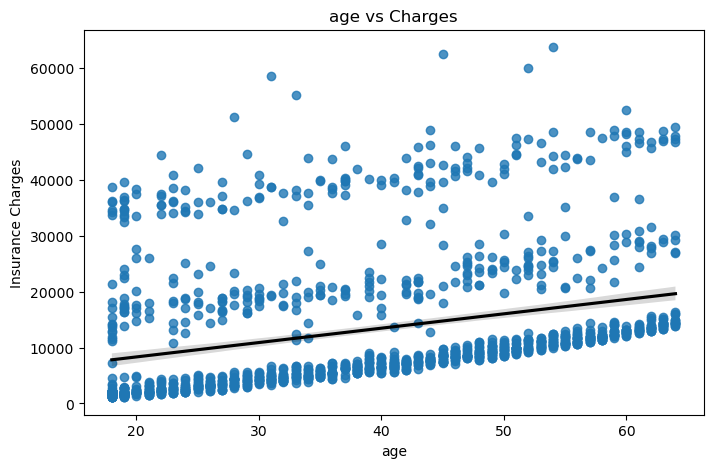

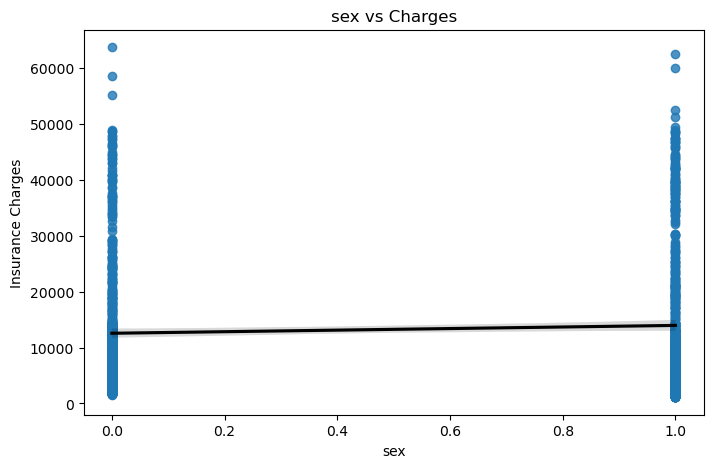

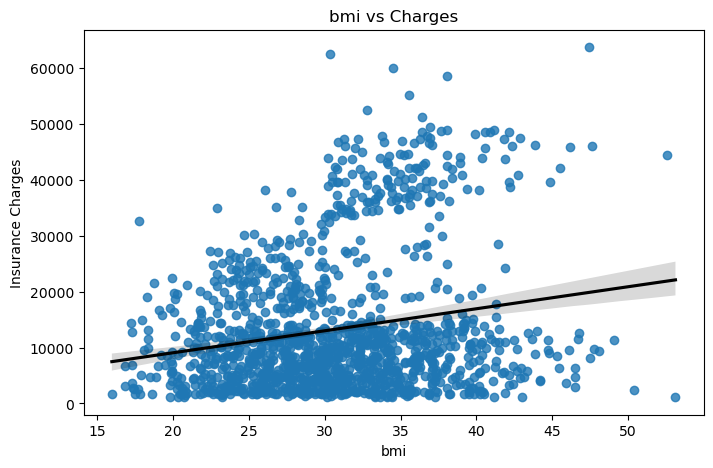

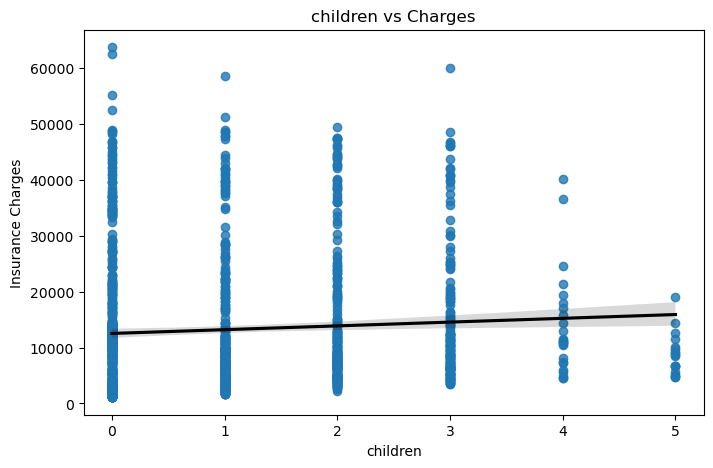

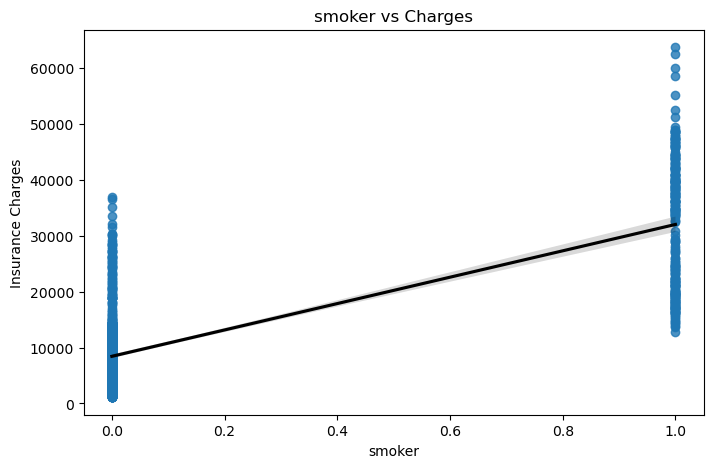

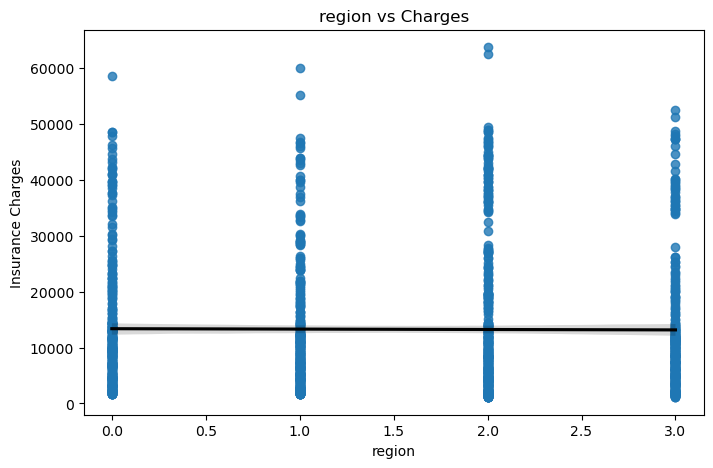

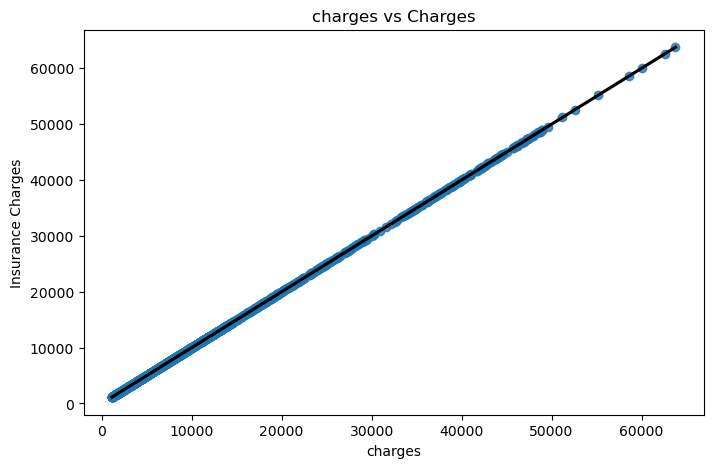

In [28]:
cols=['age', 'sex', 'bmi', 'children', 'smoker', 'region', 'charges']

for col in cols:
    plt.figure(figsize=(8,5))

    sns.regplot(
        x=df[col],
        y=df['charges'],
        line_kws={'color':'black'}
    )
    plt.xlabel(col)
    plt.ylabel("Insurance Charges")
    plt.title(f"{col} vs Charges")
    plt.show()    

### Step 13 — Model Evaluation

In [29]:
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)

Mean Absolute Error: 4182.353155288296
Mean Squared Error: 35493102.61165053
Root Mean Squared Error: 5957.60879981646
R2 Score: 0.8068466322629111


### Step 14 — Actual vs Predicted Values

In [30]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})
results.head(10)
#store actual and predicted values to result and display 10 datas

,Actual,Predicted
900,8688.85885,8080.450186
1064,5708.86700,5592.871120
1256,11436.73815,14378.298655
298,38746.35510,31731.819541
237,4463.20510,9158.356944
481,9304.70190,13361.014269
240,38511.62830,30257.655258
277,2150.46900,1308.647356
415,7345.72660,10849.425445
707,10264.44210,11375.548519


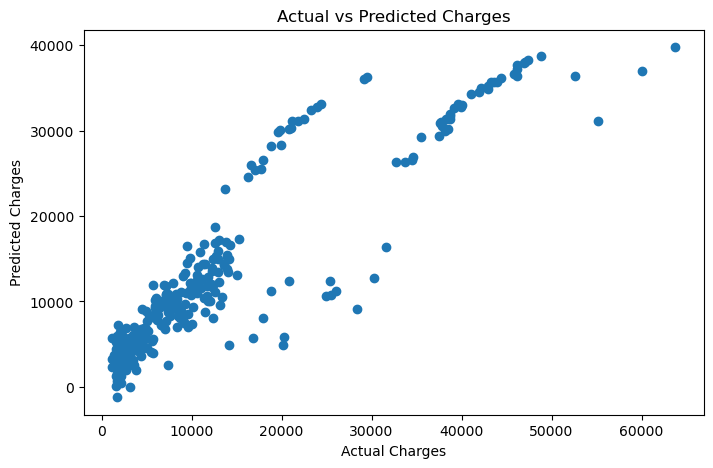

In [31]:
plt.figure(figsize=(8,5))
plt.scatter(y_test, y_pred)
#plt.plot(y_test,y_pred,color='green',marker='o')
plt.xlabel("Actual Charges")
plt.ylabel("Predicted Charges")
plt.title("Actual vs Predicted Charges")
plt.show()
#actual and predicted value ploted together

### Step 15 — Business Insights

- Smokers generally have higher insurance charges.
- BMI and age influence medical costs.
- Linear Regression can predict insurance charges with reasonable accuracy.

### Step 16 — Conclusion

In this project, we:
- Performed data preprocessing
- Conducted EDA
- Built a Linear Regression model
- Evaluated the model using regression metrics

This project demonstrates how Machine Learning can be used in healthcare cost prediction.

# Improvements
#### 1.Ridge Regression

What is Ridge Regression?

Ridge Regression is an improved version of Linear Regression that helps reduce:

overfitting
unstable coefficients
excessive feature influence

It adds a penalty term.

| Alpha | Effect                         |
| ----- | ------------------------------ |
| small | behaves like linear regression |
| large | stronger regularization        |


### Step 17 - RIDGE REGRESSION

In [32]:
from sklearn.linear_model import Ridge

# Create model
ridge_model = Ridge(alpha=1.0)

# Train model
ridge_model.fit(X_train, y_train)

# Predict
ridge_pred = ridge_model.predict(X_test)

# Evaluate
ridge_r2 = r2_score(y_test, ridge_pred)

print("Ridge Regression R2 Score:", ridge_r2)

Ridge Regression R2 Score: 0.8058993545084215


#### 2.What is Lasso?

Lasso:

reduces overfitting
performs feature selection

#### Step 18 - LASSO REGRESSION

In [33]:
from sklearn.linear_model import Lasso

# Create model
lasso_model = Lasso(alpha=0.1)

# Train model
lasso_model.fit(X_train, y_train)

# Predict
lasso_pred = lasso_model.predict(X_test)

# Evaluate
lasso_r2 = r2_score(y_test, lasso_pred)

print("Lasso Regression R2 Score:", lasso_r2)

Lasso Regression R2 Score: 0.8068415726317475


#### Feature Scaling
Why scaling matters?

Features have different ranges:
| Feature | Example |
| ------- | ------- |
| age     | 25      |
| bmi     | 31      |
| charges | 50000   |


Large-value features can dominate learning so we use the solution:
z = (x - μ) /σ

#### Step 19 - Feature Scaling

In [34]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=42
)
model = LinearRegression()
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("Mean Absolute Error:", mae)
print("Mean Squared Error:", mse)
print("Root Mean Squared Error:", rmse)
print("R2 Score:", r2)



Mean Absolute Error: 4182.353155288298
Mean Squared Error: 35493102.61165052
Root Mean Squared Error: 5957.608799816459
R2 Score: 0.8068466322629111


#### Random Forest
What is Random Forest?

It creates:

many decision trees
combines their predictions

Like asking 100 mini-experts instead of 1.

#### Step 20 - Random Forest

In [35]:
from sklearn.ensemble import RandomForestRegressor

# Create model
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

# Train
rf_model.fit(X_train, y_train)

# Predict
rf_pred = rf_model.predict(X_test)

# Evaluate
rf_r2 = r2_score(y_test, rf_pred)

print("Random Forest R2 Score:", rf_r2)

Random Forest R2 Score: 0.8828131251706088


#### comparison of models

In [36]:
results = pd.DataFrame({

    'Model': [
        'Linear Regression',
        'Ridge Regression',
        'Lasso Regression',
        'Random Forest'
    ],

    'R2 Score': [
        r2,
        ridge_r2,
        lasso_r2,
        rf_r2
    ]

})

print(results)

               Model  R2 Score
0  Linear Regression  0.806847
1   Ridge Regression  0.805899
2   Lasso Regression  0.806842
3      Random Forest  0.882813
